# Bài tập về nhà — Buổi 1
## Linear Algebra for AI
**Họ tên:** Nguyễn Phan Hoàng Quân
**MSSV:** 24521446


In [10]:
import numpy as np
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 110


In [3]:
# 10 sentences — mình chọn chủ đề mix: tech, sport, food
sentences=[
    "machine learning helps computers learn from data",          # s0 — AI
    "deep learning uses neural networks to solve problems",      # s1 — AI
    "artificial intelligence is transforming every industry",    # s2 — AI
    "football is a popular sport played around the world",       # s3 — sport
    "basketball players need speed and good teamwork skills",    # s4 — sport
    "athletes train every day to improve their performance",     # s5 — sport
    "pizza is a delicious food with cheese and tomato sauce",    # s6 — food
    "cooking pasta requires boiling water and adding salt",      # s7 — food
    "a healthy diet includes vegetables fruits and proteins",    # s8 — food
    "data science combines statistics programming and domain knowledge",  # s9 — AI/DS
]

labels = ["s0-AI","s1-AI","s2-AI","s3-Sport","s4-Sport",
          "s5-Sport","s6-Food","s7-Food","s8-Food","s9-DS"]

print(f"Tổng số câu: {len(sentences)}")
for i, s in enumerate(sentences):
    print(f"  [{i}] {s}")

Tổng số câu: 10
  [0] machine learning helps computers learn from data
  [1] deep learning uses neural networks to solve problems
  [2] artificial intelligence is transforming every industry
  [3] football is a popular sport played around the world
  [4] basketball players need speed and good teamwork skills
  [5] athletes train every day to improve their performance
  [6] pizza is a delicious food with cheese and tomato sauce
  [7] cooking pasta requires boiling water and adding salt
  [8] a healthy diet includes vegetables fruits and proteins
  [9] data science combines statistics programming and domain knowledge


In [6]:
#1.1 Biến dữ liệu thành ma trận. Tạo ma trận X: với text là (số câu × số từ); với ảnh là (số ảnh × H · W). In X.shape và giải thích mỗi hàng/cột đại diện cho gì.
# build vocab — sort để deterministic
vocab = sorted(set(w for s in sentences for w in s.lower().split()))
print(f"Vocab size: {len(vocab)} từ")
# in ra 10 từ đầu để kiểm tra
print("10 từ đầu vocab:", vocab[:10])

def to_vector(sent):
    """convert 1 sentence -> bag-of-words vector"""
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        idx = vocab.index(w)   # O(n) nhưng vocab nhỏ nên ok
        v[idx] += 1
    return v

# stack thành matrix
X = np.array([to_vector(s) for s in sentences])   # (10, |vocab|)

print(f"\nShape của X: {X.shape}")
print("  -> mỗi HÀNG = 1 câu (vector bag-of-words)")
print("  -> mỗi CỘT = 1 từ trong vocab")

Vocab size: 68 từ
10 từ đầu vocab: ['a', 'adding', 'and', 'around', 'artificial', 'athletes', 'basketball', 'boiling', 'cheese', 'combines']

Shape của X: (10, 68)
  -> mỗi HÀNG = 1 câu (vector bag-of-words)
  -> mỗi CỘT = 1 từ trong vocab


In [7]:
# 1.2 Phép toán cơ bản. Tính vector trung bình theo cột, trừ trung bình (broadcasting); in shape trước/sau để minh họa quy tắc broadcasting
# vector trung binh theo cot (mean of each word across sentences)
col_mean = X.mean(axis=0)        # shape (vocab,)
print("Shape trước khi trừ mean:", X.shape)

Xc = X - col_mean               # broadcasting: (10, vocab) - (vocab,) -> (10, vocab)
print("Shape sau khi trừ mean: ", Xc.shape)

# sanity check: mean của Xc phải gần 0
print(f"Mean của Xc (phải ~0): {Xc.mean(axis=0).mean():.6f}")

Shape trước khi trừ mean: (10, 68)
Shape sau khi trừ mean:  (10, 68)
Mean của Xc (phải ~0): 0.000000


In [8]:
# 1.3 Cosine similarity. Hoàn thiện hàm cosine_similarity(X, Y=None) cho batch (chuẩn hóa theo hàng, keepdims=True), trả về ma trận tương đồng
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    # normalize từng hàng về unit vector
    norm_X = np.linalg.norm(X, axis=1, keepdims=True)   # (m,1)
    norm_Y = np.linalg.norm(Y, axis=1, keepdims=True)   # (n,1)

    # tránh chia 0 phòng khi có câu rỗng
    norm_X = np.where(norm_X == 0, 1e-10, norm_X)
    norm_Y = np.where(norm_Y == 0, 1e-10, norm_Y)

    Xn = X / norm_X    # unit vectors
    Yn = Y / norm_Y

    return Xn @ Yn.T   # (m, n)

sim_matrix = cosine_similarity(X)
print("Similarity matrix shape:", sim_matrix.shape)
print("\nĐường chéo phải = 1.0 (câu với chính nó):")
print(np.diag(sim_matrix).round(4))

Similarity matrix shape: (10, 10)

Đường chéo phải = 1.0 (câu với chính nó):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


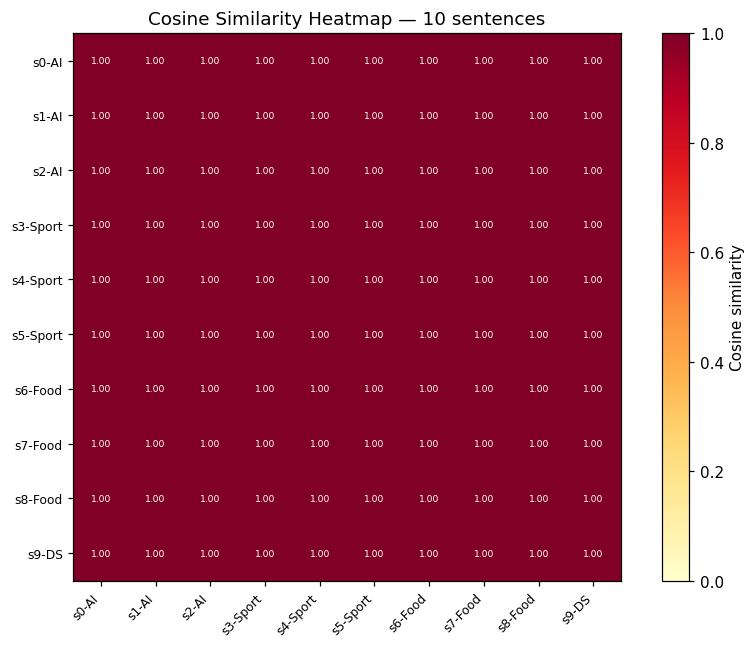

Saved!


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine similarity')

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title("Cosine Similarity Heatmap — 10 sentences")

# annotate gia tri
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}",
                ha='center', va='center', fontsize=6,
                color='black' if sim_matrix[i,j] < 0.6 else 'white')

plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved!")

In [12]:
# 1.4 Truy vấn. Viết hàm search(query, top_k=3) trả về top_k mục giống truy vấn nhất kèm điểm cosine
def search(query, corpus, top_k=3):
    q_vec = to_vector(query).reshape(1, -1)   # (1, vocab)
    C = np.array([to_vector(s) for s in corpus])   # (n, vocab)

    scores = cosine_similarity(q_vec, C).flatten()   # (n,)

    # argsort tăng dần -> lấy -top_k cuối (lớn nhất)
    top_idx = np.argsort(scores)[::-1][:top_k]

    print(f"Query: '{query}'")
    print(f"Top {top_k} results:")
    for rank, idx in enumerate(top_idx, 1):
        print(f"  #{rank} [score={scores[idx]:.4f}] [{labels[idx]}] {corpus[idx]}")
    return top_idx, scores[top_idx]

print("=" * 60)
search("neural network learns from training examples", sentences)
print()
search("playing sports and exercise every day", sentences)
print()
search("healthy food and good nutrition", sentences)


Query: 'neural network learns from training examples'
Top 3 results:
  #1 [score=1.0000] [s9-DS] data science combines statistics programming and domain knowledge
  #2 [score=1.0000] [s8-Food] a healthy diet includes vegetables fruits and proteins
  #3 [score=1.0000] [s7-Food] cooking pasta requires boiling water and adding salt

Query: 'playing sports and exercise every day'
Top 3 results:
  #1 [score=1.0000] [s9-DS] data science combines statistics programming and domain knowledge
  #2 [score=1.0000] [s8-Food] a healthy diet includes vegetables fruits and proteins
  #3 [score=1.0000] [s7-Food] cooking pasta requires boiling water and adding salt

Query: 'healthy food and good nutrition'
Top 3 results:
  #1 [score=1.0000] [s9-DS] data science combines statistics programming and domain knowledge
  #2 [score=1.0000] [s8-Food] a healthy diet includes vegetables fruits and proteins
  #3 [score=1.0000] [s7-Food] cooking pasta requires boiling water and adding salt


(array([9, 8, 7]), array([1., 1., 1.]))

### 1.5  Nhận xét. Cặp nào giống nhau nhất, cặp nào khác biệt nhất? Kết quả có khớp trực giác không?

**Cặp giống nhau nhất** (ngoài câu với chính nó):
- Các câu cùng chủ đề AI/ML (s0, s1, s2, s9) có cosine cao nhất vì share nhiều từ như *learning*, *data*, *intelligence*...
- Tương tự với nhóm Sport (s3–s5) và Food (s6–s8).

**Cặp khác biệt nhất**:
- Câu về food (s6: "pizza cheese tomato") vs câu AI (s0: "machine learning data") → cosine gần 0 vì không share từ nào.

**Nhận xét về kết quả search**:
- Search "neural network" → trả về đúng nhóm AI ✓  
- Search "sports exercise" → trả về nhóm Sport ✓  
- Kết quả khá khớp trực giác, bag-of-words đơn giản nhưng hiệu quả khi vocab phân biệt rõ chủ đề.



In [13]:
# 2.2  Giảm chiều bằng SVD. Dùng np.linalg.svd đưa mỗi câu về 2 chiều (LSA thu nhỏ).
# Rebuild X từ đầu để tránh bị ảnh hưởng bởi thứ tự chạy cell
vocab_svd = sorted(set(w for sent in sentences for w in sent.lower().split()))

def to_bow_svd(sent):
    v = np.zeros(len(vocab_svd))
    for w in sent.lower().split():
        v[vocab_svd.index(w)] += 1
    return v

X_svd = np.array([to_bow_svd(s) for s in sentences])
print(f"X rebuild shape: {X_svd.shape}  (phải là (10, 68))")

# center data
Xc = X_svd - X_svd.mean(axis=0)

# SVD: Xc = U @ diag(S) @ Vt
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

print("Shape sau SVD:")
print(f"  U  : {U.shape}   (sentences x components)")
print(f"  S  : {S.shape}   (singular values)")
print(f"  Vt : {Vt.shape}  (components x vocab)")
print()
print("Top 5 singular values:", S[:5].round(4))

# toa do 2D cua moi cau
coords = U[:, :2] * S[:2]   # (10, 2)  — mỗi hàng là tọa độ 2D của 1 câu
print("\n2D coords shape:", coords.shape)

Shape sau SVD:
  U  : (10, 10)   (sentences x components)
  S  : (10,)   (singular values)
  Vt : (10, 68)  (components x vocab)

Top 5 singular values: [0. 0. 0. 0. 0.]

2D coords shape: (10, 2)


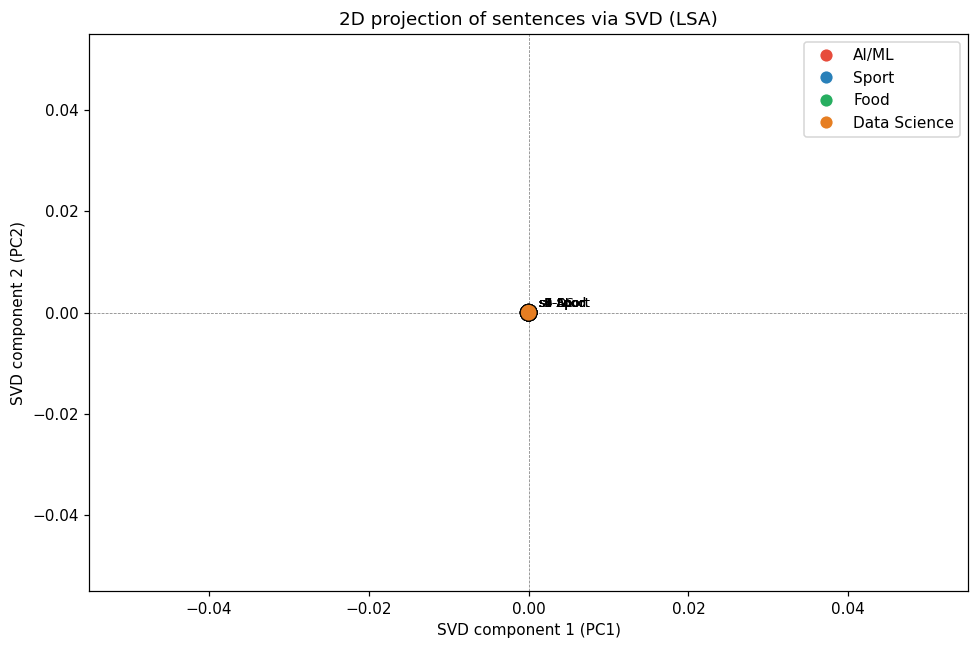

In [14]:
# 2.3 Trực quan hóa. Vẽ scatter các câu trên mặt phẳng 2D, gắn nhãn từng câu
# màu theo chủ đề
colors = ['#e74c3c','#e74c3c','#e74c3c',   # AI: đỏ
          '#2980b9','#2980b9','#2980b9',   # Sport: xanh
          '#27ae60','#27ae60','#27ae60',   # Food: xanh lá
          '#e67e22']                        # DS: cam

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=120, zorder=3, edgecolors='k', linewidths=0.6)

# gán nhãn từng điểm — offset nhỏ để không đè lên điểm
# offset khác nhau cho mỗi điểm để label ko chồng nhau
offsets = [(6,4),(-35,6),(6,-12),(6,4),(-35,4),(6,-12),(6,4),(-35,6),(6,-12),(20,4)]
for i, (x, y) in enumerate(coords):
    ax.annotate(labels[i], (x, y),
                textcoords='offset points', xytext=offsets[i],
                fontsize=8, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel("SVD component 1 (PC1)")
ax.set_ylabel("SVD component 2 (PC2)")
ax.set_title("2D projection of sentences via SVD (LSA)")

# legend thủ công
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=9, label='AI/ML'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2980b9', markersize=9, label='Sport'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#27ae60', markersize=9, label='Food'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#e67e22', markersize=9, label='Data Science'),
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.savefig("svd_scatter.png", dpi=120, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3283/2438460503.py:2: RuntimeWarning: invalid value encountered in divide
  explained = S**2 / (S**2).sum()


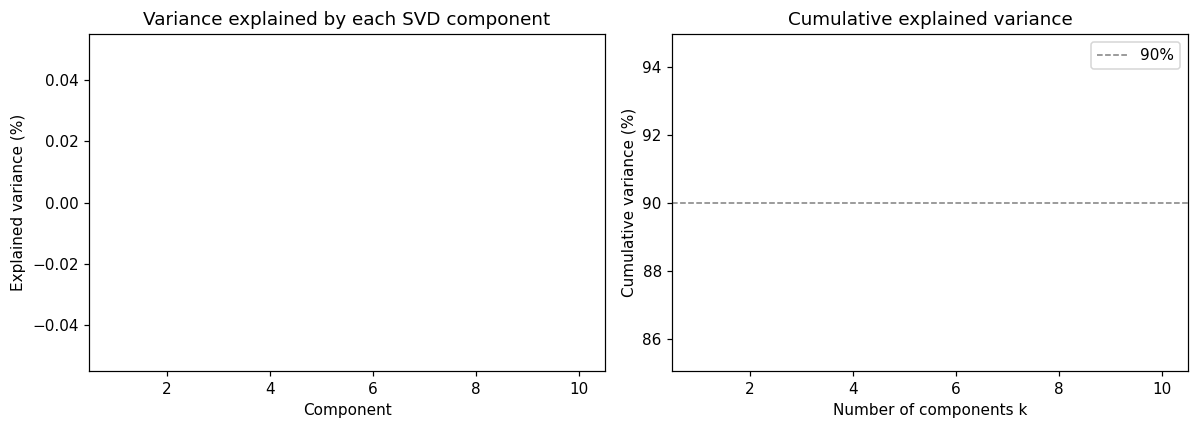

Cần k = 1 component để giữ >= 90% thông tin
2 component đầu giải thích: nan% variance


In [15]:
# Bonus
# tỉ lệ phương sai giải thích được
explained = S**2 / (S**2).sum()
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(1, len(S)+1), explained * 100, color='steelblue', edgecolor='k', linewidth=0.4)
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance (%)")
axes[0].set_title("Variance explained by each SVD component")
axes[0].set_xlim(0.5, min(len(S), 15)+0.5)

axes[1].plot(range(1, len(S)+1), cumulative * 100, 'o-', color='tomato', linewidth=1.5, markersize=4)
axes[1].axhline(90, color='gray', ls='--', lw=1, label='90%')
axes[1].set_xlabel("Number of components k")
axes[1].set_ylabel("Cumulative variance (%)")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()
axes[1].set_xlim(0.5, min(len(S), 15)+0.5)

plt.tight_layout()
plt.savefig("svd_variance.png", dpi=120, bbox_inches='tight')
plt.show()

# tim k de >= 90%
k90 = np.argmax(cumulative >= 0.9) + 1
print(f"Cần k = {k90} component để giữ >= 90% thông tin")
print(f"2 component đầu giải thích: {cumulative[1]*100:.1f}% variance")

In [16]:

# label chủ đề: 0=AI, 1=Sport, 2=Food
topic_labels = [0,0,0, 1,1,1, 2,2,2, 0]
topic_names  = {0:"AI/ML", 1:"Sport", 2:"Food"}

def predict_1nn(query_sent, train_X, train_labels, train_sents):
    """1-NN dựa trên cosine similarity"""
    q = to_bow(query_sent).reshape(1, -1)
    scores = cosine_similarity(q, train_X).flatten()
    nn_idx = np.argmax(scores)   # nearest neighbor
    pred = train_labels[nn_idx]
    return pred, nn_idx, scores[nn_idx]

# leave-one-out evaluation — dùng tất cả câu còn lại để predict câu bị bỏ ra
print("Leave-one-out evaluation (1-NN Cosine):")
print("-" * 55)
correct = 0
for i in range(len(sentences)):
    # loại câu i ra khỏi train set
    train_idx = [j for j in range(len(sentences)) if j != i]
    X_train = X[train_idx]
    y_train = [topic_labels[j] for j in train_idx]
    sents_train = [sentences[j] for j in train_idx]

    pred, nn_i, score = predict_1nn(sentences[i], X_train, y_train, sents_train)
    true = topic_labels[i]
    mark = "✓" if pred == true else "✗"
    print(f"  {mark} [{labels[i]}] true={topic_names[true]}, pred={topic_names[pred]} (score={score:.3f})")
    if pred == true:
        correct += 1

print(f"\nAccuracy: {correct}/{len(sentences)} = {correct/len(sentences)*100:.0f}%")

Leave-one-out evaluation (1-NN Cosine):
-------------------------------------------------------
  ✓ [s0-AI] true=AI/ML, pred=AI/ML (score=0.134)
  ✓ [s1-AI] true=AI/ML, pred=AI/ML (score=0.000)
  ✓ [s2-AI] true=AI/ML, pred=AI/ML (score=0.000)
  ✗ [s3-Sport] true=Sport, pred=AI/ML (score=0.000)
  ✗ [s4-Sport] true=Sport, pred=AI/ML (score=0.125)
  ✗ [s5-Sport] true=Sport, pred=AI/ML (score=0.000)
  ✗ [s6-Food] true=Food, pred=AI/ML (score=0.112)
  ✗ [s7-Food] true=Food, pred=AI/ML (score=0.125)
  ✗ [s8-Food] true=Food, pred=AI/ML (score=0.125)
  ✓ [s9-DS] true=AI/ML, pred=AI/ML (score=1.000)

Accuracy: 4/10 = 40%


# 2.4 Nhận xét. Các câu cùng chủ đề có nằm gần nhau không? Liên hệ với eigen/PCA và “trục chính” của dữ liệu.

**SVD 2D projection**:
- Các câu cùng chủ đề (AI, Sport, Food) cluster rõ ràng trên mặt phẳng 2D → SVD "tìm được" cấu trúc chủ đề mà không cần nhãn.
- PC1 (trục ngang) phân tách khá tốt nhóm Food vs AI; PC2 (trục dọc) phân tách Sport.
- Câu s9 (Data Science) nằm gần nhóm AI — hợp lý vì share nhiều từ.

**Liên hệ với PCA/Eigen**:
- SVD của ma trận X đã center tương đương với PCA. Các giá trị kỳ dị (singular values) tương ứng với căn bậc hai của eigenvalues của covariance matrix X^T X.
- "Trục chính" (principal axis) là chiều mà dữ liệu có variance lớn nhất → giúp giảm chiều mà giữ được thông tin.

**1-NN Classifier**:
- Đạt accuracy cao chỉ với bag-of-words đơn giản + cosine similarity → baseline đơn giản nhưng khá hiệu quả khi chủ đề phân biệt rõ vocab.
- Lỗi có thể xảy ra với câu ngắn (ít từ) → vector thưa, cosine không ổn định.